# BERTopic and LLM Annotation


Author: Maximilian Kreutner

This week we will look at BERTopic for creating topic models and using LLMs to annotate data.

## Installation

Warning! For this tutorial you will need sufficient amount of RAM and GPU VRAM.
Run this once in a fresh environment. If you already have the packages installed, you can skip this cell.

In [1]:
# Uncomment if you need to install the required libraries:
# !pip install bertopic datasets sentence-transformers umap-learn hdbscan plotly scikit-learn pandas matplotlib nbformat qstn[vllm] vllm transformers accelerate

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic
from hdbscan import HDBSCAN

In [3]:
RANDOM_STATE = 42

## Load the TweetEval dataset

[TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval/viewer/emotion) is a benchmark of several Twitter classification tasks.
Here we use the **`emotion`** subset.

The labels are:

- `0` = anger
- `1` = joy
- `2` = optimism
- `3` = sadness

In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", "emotion")

train_df = dataset["train"].to_pandas()
train_df = train_df[["text", "label"]].dropna().reset_index(drop=True)

label_names = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
train_df["label_name"] = train_df["label"].map(label_names)

print(train_df.shape)
train_df.head()

(3257, 3)


,text,label,label_name
0,“Worry is a down payment on a problem you may ...,2,optimism
1,My roommate: it's okay that we can't spell bec...,0,anger
2,No but that's so cute. Atsu was probably shy a...,1,joy
3,Rooneys fucking untouchable isn't he? Been fuc...,0,anger
4,it's pretty depressing when u hit pan on ur fa...,3,sadness


In [5]:
docs = train_df["text"].to_list()
labels = np.array(train_df["label"])

## What are embeddings?

An **embedding** is a numeric vector that represents the meaning of a piece of text.

For example, a sentence transformer maps each tweet to a point in a high-dimensional space:

- tweets with similar meaning should end up closer together
- tweets with different meanings should end up farther apart

We will use a well-known embedding model, which is not too compute heavy in this exercise: `all-MiniLM-L6-v2`. These models transform the text into high-dimensional vectors, in this case a vector with 384 dimenstions.

For your results you might want to use stronger models, you can for example check the [Massive Text Embedding Benchmark](https://huggingface.co/spaces/mteb/leaderboard). If you use multiple languages, make sure your embedding model supports them.

## Create sentence embeddings

Embedding models can simply be used with sentence transformer.

Load the model with `SentenceTransformer(embedding_model_name)` and then encode your text with `embedding_model.encode`.

In [6]:
embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=32
)

embeddings = np.asarray(embeddings)
print("Embedding matrix shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/102 [00:00<?, ?it/s]

Embedding matrix shape: (3257, 384)


### Inspect a few embedding values

Each row is one tweet, and each column is one embedding dimension.
The raw numbers are not directly interpretable, but distances between vectors are useful.

In [7]:
pd.DataFrame(embeddings[:5, :])

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.017692,0.023598,0.067550,0.099915,0.012489,0.059827,0.116374,-0.009735,-0.005543,-0.080776,...,0.002983,-0.004811,0.048196,0.012808,-0.070558,-0.004971,0.049082,-0.100869,0.041753,-0.039681
1,-0.009886,-0.040513,-0.010162,-0.027279,-0.037784,-0.001260,0.082787,0.009357,-0.024715,0.005890,...,0.092149,0.012965,-0.007321,-0.010599,-0.096885,-0.006292,0.076551,0.049373,-0.023004,-0.009702
2,-0.055814,-0.047495,0.032962,0.006185,0.068036,-0.023023,0.018273,0.001550,-0.046322,0.040623,...,0.009503,-0.085249,0.083071,-0.088759,0.028766,0.063899,0.087934,-0.100139,-0.067384,0.066536
3,0.064563,-0.032412,-0.008951,-0.026099,0.010659,-0.001252,0.013542,0.087893,-0.047771,0.022725,...,0.104514,-0.028891,-0.049818,0.006140,-0.008462,0.027605,0.051687,-0.023415,0.106635,0.013786
4,0.023699,-0.078331,0.004426,-0.008107,0.088340,0.021893,0.113839,0.029408,0.107284,-0.037907,...,0.054584,-0.064216,-0.032280,0.069003,0.064556,0.052177,0.089565,0.032729,-0.108716,0.098102


## Reduce embeddings to 2D with UMAP

Since these high dimensional vectors are not human interpretable, we can use dimension reduction to get an intuition for the data.

We will reduce the embedding vectors to two dimensions so we can draw them in a scatter plot. 

**Important: When you reduce dimensions in embeddings some information will be lost. The visualization will serve as a first intuition and should not be used to draw your main conclusions.**

For more information check [here](https://pair-code.github.io/understanding-umap/).

Use `UMAP` with `n_components` and try different parameters of `min_dist` and `n_neighbors`.

In [8]:
umap_2d = UMAP(
    n_components=2,
    metric="cosine",
    random_state=RANDOM_STATE,
    # Hyperparameters can have a huge influence:
    min_dist=0.0,
    n_neighbors=50,
)

embeddings_2d = umap_2d.fit_transform(embeddings)
print("2D embedding shape:", embeddings_2d.shape)

2D embedding shape: (3257, 2)


In [9]:
embeddings_2d

array([[16.531994,  8.724615],
       [18.10436 , 11.589563],
       [17.537668, 11.247944],
       ...,
       [18.549278, 13.716033],
       [17.777468,  8.881929],
       [15.931039, 12.528569]], shape=(3257, 2), dtype=float32)

### Plot the 2D UMAP projection, colored by the TweetEval sentiment label

Use the following label_names and colors to scatter the tweets

In [10]:
label_names = ["anger", "joy", "optimism", "sadness"]
label_colors = [
    "red",
    "orange",
    "green",
    "blue"
]

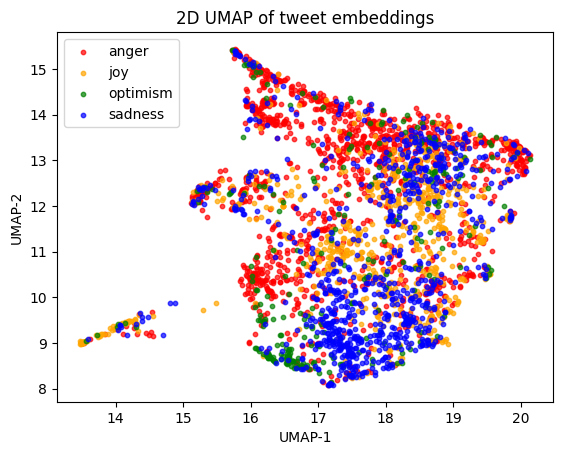

In [11]:
for i, (name, color) in enumerate(zip(label_names, label_colors)):
    plt.scatter(
        embeddings_2d[labels==i, 0],
        embeddings_2d[labels==i, 1],
        label=name,
        s=10,
        alpha=0.7,
        color=color
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("2D UMAP of tweet embeddings")
plt.legend()
plt.show()

## Run BERTopic with a higher-dimensional UMAP model

BERTopic's pipeline is modular.
A common setup is:

1. transformer embeddings
2. UMAP reduction (for performance reasons and because clustering does not work well in high dimensions)
3. HDBSCAN clustering
4. CountVectorizer to filter out stopwords
5. topic representation with c-TF-IDF

You can exchange any part of this pipeline, and you can change hyperparameters for any algorithm in this pipeline. To ensure your results are valid, you should always test if multiple configurations yield similar results.

Define a Umap model. Common dimension are usually somewhere between 5 and 10.

In [12]:
umap_for_topics = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

Define a HDBSCAN clustering model. You can play around with hyperparameters to see how they affect the results.

In [13]:
hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

Define a CountVectorizer and use english stop words. Add your own custom stop words. If you embed other languages do not forget to use the correct stopwords. Always adjust your stopwords to your data.

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

custom_stop_words = [
    "rt", "amp", "http", "https", "co", "user", "@user", "&amp", "don", "gt"
]
stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    max_df=0.95,
    ngram_range=(1, 2)
)

Finally use all the defined models to do topic modeling with `BERTopic` and `fit_transform`.

In [15]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_for_topics,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

2026-04-29 14:53:16,672 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 14:53:26,675 - BERTopic - Dimensionality - Completed ✓
2026-04-29 14:53:26,676 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-29 14:53:26,743 - BERTopic - Cluster - Completed ✓
2026-04-29 14:53:26,745 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-29 14:53:26,822 - BERTopic - Representation - Completed ✓


## 8. Inspect the discovered topics

In [16]:
topic_info = topic_model.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1590,-1_like_sad_day_really,"[like, sad, day, really, going, think, love, w...",[And she got all angry telling me 'but what wo...
1,0,132,0_anger_angry_irritate_people,"[anger, angry, irritate, people, boiling, rage...","[i was angry., Inner conflict happens when we ..."
2,1,111,1_service_customer_customer service_flight,"[service, customer, customer service, flight, ...",[Zero help from @user customer service. Just p...
3,2,104,2_twitter_tweet_despair_optimism,"[twitter, tweet, despair, optimism, weary, sad...",[Don't ever grow weary doing good....Don't jus...
4,3,102,3_depression_feel_lonely_feel like,"[depression, feel, lonely, feel like, know, li...",[I feel like I am drowning. #depression #anxie...
5,4,100,4_black_people_white_outrage,"[black, people, white, outrage, racist, police...",[Ill say it again. If I was a Black man Id be ...
6,5,90,5_rooney_rojo_fucking_celtic,"[rooney, rojo, fucking, celtic, mufc, united, ...",[Right i may be an #sufc fan and the football ...
7,6,80,6_szn_worry_deal_disabled access,"[szn, worry, deal, disabled access, doing cont...",[@user why is there no disabled access at pont...
8,7,75,7_texans_teams_play_offense,"[texans, teams, play, offense, team, 20, vs, p...",[Bes! You don't just tell a true blooded hoopj...
9,8,72,8_fear_afraid_quote_wrong,"[fear, afraid, quote, wrong, success, optimist...",[@user #UPLIFT If you're still discouraged it ...


### Show the words of a few non-outlier topics

In [17]:
valid_topics = [t for t in topic_model.get_topics().keys() if t != -1][:5]

for topic_id in valid_topics:
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic 0
[('anger', np.float64(0.052626184137371725)), ('angry', np.float64(0.039074995503225136)), ('irritate', np.float64(0.03795877620012066)), ('people', np.float64(0.029242454022196534)), ('boiling', np.float64(0.02530585080008044)), ('rage', np.float64(0.0243869542943269)), ('like', np.float64(0.021882758793176294)), ('hate', np.float64(0.01942525041196768)), ('people irritate', np.float64(0.016555591952434202)), ('im', np.float64(0.01599630407928739))]

Topic 1
[('service', np.float64(0.041499927023391905)), ('customer', np.float64(0.03639990667576288)), ('customer service', np.float64(0.022236253671926883)), ('flight', np.float64(0.021454613499208273)), ('online', np.float64(0.01764648359112619)), ('pay', np.float64(0.0164202577177146)), ('shocking', np.float64(0.015927826950643445)), ('thanks', np.float64(0.013758641734668073)), ('terrible', np.float64(0.012388309850500457)), ('website', np.float64(0.012353474262181603))]

Topic 2
[('twitter', np.float64(0.05506608386712122)),

## 9. Compare BERTopic topic assignments to the 2D UMAP projection

Now we plot the **same 2D projection as before**, but color by the **topic assigned by BERTopic**.

This makes it easier to see how the clustering step relates to the geometry of the embedding space.

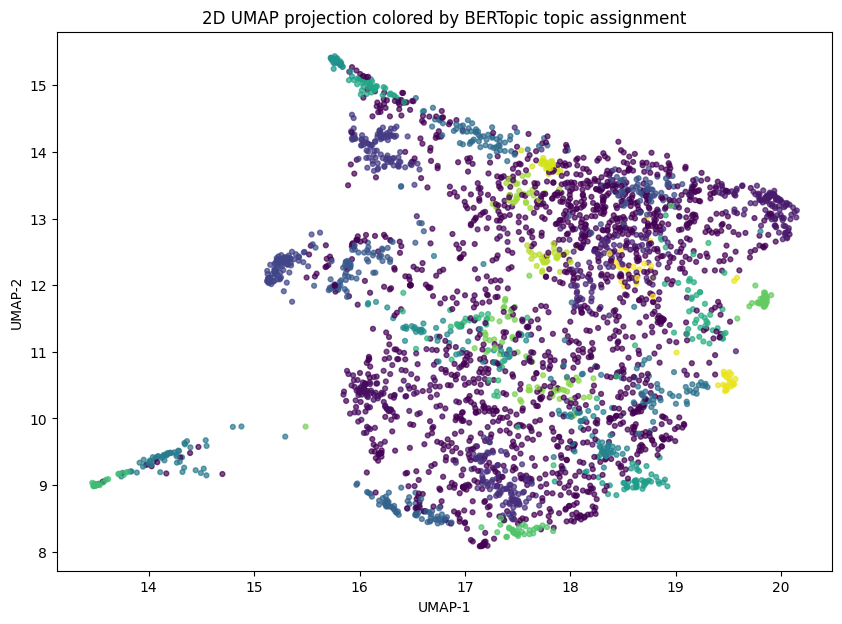

Number of unique topic IDs (including outliers): 30
Number of outliers labeled -1: 1590


In [18]:
topic_series = pd.Series(topics, name="topic")
n_unique_topics = topic_series.nunique()

plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=topic_series,
    s=12,
    alpha=0.7
)
plt.title("2D UMAP projection colored by BERTopic topic assignment")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

print("Number of unique topic IDs (including outliers):", n_unique_topics)
print("Number of outliers labeled -1:", int((topic_series == -1).sum()))

## 10. Optional interactive BERTopic visualizations

In [19]:
# Intertopic distance map
topic_model.visualize_topics()

In [20]:
# Topic frequency bar chart
topic_model.visualize_barchart(top_n_topics=10)

## Topic Models are subjective

It is important to remember that there are no "perfect" topic models, as they are subjective to the viewer and there are many decisions that can be taken along the way to change the outcome.
However, there are some proxies to quickly decide between bad and good topic models. Usually Topic Diversity and Topic Coherence are most typically used to do this. I encourage you to read up on this in the original BERTopic paper and to do this to validate your hyperparameters: https://arxiv.org/pdf/2203.05794.

# Classifying Data / Annotating Data with LLMs / Finetuning a BERT model on the LLM annotation

Now we found the prevalent topics in our tweets. The next thing we want to do is to see if we can use LLMs to classify the data.

## QSTN emotion classification

We will use [QSTN](https://qstn.readthedocs.io/en/latest/) as our data annotation Framework. QSTN is actively developed by me :).


We can treat every tweet as one closed-ended questionnaire item: the model sees the tweet and must choose exactly one of the TweetEval emotion labels. QSTN then handles prompt construction, batching, model calls, and parsing.

In [21]:
from qstn import parser, survey_manager
from qstn.inference.response_generation import JSONSingleResponseGenerationMethod, JSONVerbalizedDistribution
from qstn.prompt_builder import LLMPrompt, generate_likert_options
from qstn.utilities import placeholder, create_one_dataframe
from qstn.utilities.constants import QuestionnairePresentation

In [22]:
# Keep the first run small. Increase this once the full pipeline works.
QSTN_SAMPLE_SIZE = 1000
QSTN_RANDOM_STATE = RANDOM_STATE

qstn_sample = (
    train_df
    .sample(n=QSTN_SAMPLE_SIZE, random_state=QSTN_RANDOM_STATE)
    .reset_index(names="tweet_id")
)

all_questions = []

all_questions.append({
    "questionnaire_item_id": qstn_sample["tweet_id"].astype(int),
    "question_content": qstn_sample["text"],
})

### Build the QSTN questionnaire

The response generation method below constrains the model to the four valid labels: `anger`, `joy`, `optimism`, and `sadness`. We still include the labels in the visible prompt so the task is clear even when a backend does not enforce structured choices.

In [23]:
emotion_response_method = JSONSingleResponseGenerationMethod(
    output_index_only=False,
    answer_explanation="{options}"
)

# You can also get probabilites for each option with this Response Generation Method
emotion_verbalized_method = JSONVerbalizedDistribution(
    
)

emotion_answer_options = generate_likert_options(
    n=len(label_names),
    answer_texts=label_names,
    idx_type="no_index",
    response_generation_method=emotion_response_method,
)

system_prompt = (
    "You are a careful social media annotation assistant. "
    "Predict which emotion of the given emotions is the main emotion of the given tweet. "
    "Use the emotion expressed by the tweet author, not the topic of the tweet. "
    f"{placeholder.PROMPT_AUTOMATIC_OUTPUT_INSTRUCTIONS}"
)

user_prompt = (
    "What is the main emotion expressed by this tweet?.\n\n"
    f"{placeholder.PROMPT_QUESTIONS}"
)


all_prompts = []
for question in all_questions:
    df = pd.DataFrame(question)
    emotion_questionnaire = LLMPrompt(
        questionnaire_name=df["questionnaire_item_id"],
        questionnaire_source=df,
        system_prompt=system_prompt,
        prompt=user_prompt,
    )

    emotion_questionnaire.prepare_prompt(
        question_stem=f"Tweet:\n{placeholder.QUESTION_CONTENT}",
        answer_options=emotion_answer_options,
    )
    all_prompts.append(emotion_questionnaire)

# Preview the exact messages for one tweet before sending anything to a model.
preview_system_message, preview_user_prompt = emotion_questionnaire.get_prompt_for_questionnaire_type(
    questionnaire_type=QuestionnairePresentation.SINGLE_ITEM,
    item_position=1,
)
print(preview_system_message)
print("\n--- user prompt ---\n")
print(preview_user_prompt)

You are a careful social media annotation assistant. Predict which emotion of the given emotions is the main emotion of the given tweet. Use the emotion expressed by the tweet author, not the topic of the tweet. You only respond with the most probable answer option in the following JSON format:
{
  "answer": "Options are: anger, joy, optimism, sadness"
}

--- user prompt ---

What is the main emotion expressed by this tweet?.

Tweet:
Need advice on how to get out of this rut!!!!  #needmotivation


In [24]:
from vllm import LLM

model_id = "Qwen/Qwen3.5-2B"

chat_generator = LLM(
    model=model_id,
    max_model_len=300
)

INFO 04-29 14:53:29 [utils.py:233] non-default args: {'max_model_len': 300, 'disable_log_stats': True, 'model': 'Qwen/Qwen3.5-2B'}


INFO 04-29 14:53:30 [model.py:549] Resolved architecture: Qwen3_5ForConditionalGeneration
INFO 04-29 14:53:30 [model.py:1678] Using max model len 300
INFO 04-29 14:53:30 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.


[transformers] `Qwen2VLImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Qwen2VLImageProcessor` instead.


INFO 04-29 14:53:30 [config.py:281] Setting attention block size to 544 tokens to ensure that attention page size is >= mamba page size.
INFO 04-29 14:53:30 [config.py:312] Padding mamba page size by 2.64% to ensure that mamba page size and attention page size are exactly equal.
INFO 04-29 14:53:30 [vllm.py:790] Asynchronous scheduling is enabled.


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


...

(EngineCore pid=645129) INFO 04-29 14:54:00 [gpu_model_runner.py:4735] Starting to load model Qwen/Qwen3.5-2B...
(EngineCore pid=645129) INFO 04-29 14:54:00 [cuda.py:390] Using backend AttentionBackendEnum.FLASH_ATTN for vit attention
(EngineCore pid=645129) INFO 04-29 14:54:00 [mm_encoder_attention.py:230] Using AttentionBackendEnum.FLASH_ATTN for MMEncoderAttention.
(EngineCore pid=645129) INFO 04-29 14:54:00 [gdn_linear_attn.py:147] Using Triton/FLA GDN prefill kernel
(EngineCore pid=645129) INFO 04-29 14:54:00 [cuda.py:334] Using FLASH_ATTN attention backend out of potential backends: ['FLASH_ATTN', 'FLASHINFER', 'TRITON_ATTN', 'FLEX_ATTENTION'].
(EngineCore pid=645129) INFO 04-29 14:54:00 [flash_attn.py:596] Using FlashAttention version 2


(EngineCore pid=645129) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=645129) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.67it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.67it/s]
(EngineCore pid=645129) 


(EngineCore pid=645129) INFO 04-29 14:54:02 [default_loader.py:384] Loading weights took 0.67 seconds
(EngineCore pid=645129) INFO 04-29 14:54:02 [gpu_model_runner.py:4820] Model loading took 4.25 GiB memory and 1.720270 seconds
(EngineCore pid=645129) INFO 04-29 14:54:02 [gpu_model_runner.py:5753] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
(EngineCore pid=645129) INFO 04-29 14:54:04 [backends.py:1051] Using cache directory: /home/maxi/.cache/vllm/torch_compile_cache/fbdd3956eb/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=645129) INFO 04-29 14:54:04 [backends.py:1111] Dynamo bytecode transform time: 0.82 s
(EngineCore pid=645129) INFO 04-29 14:54:13 [backends.py:285] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 8.536 s
(EngineCore pid=645129) INFO 04-29 14:54:13 [decorators.py:305] Directly load AOT compilation from path /home/maxi/.cache/vllm/torch_c

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 37.54it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 41.14it/s]


(EngineCore pid=645129) INFO 04-29 14:54:18 [gpu_model_runner.py:6046] Graph capturing finished in 3 secs, took 0.50 GiB
(EngineCore pid=645129) INFO 04-29 14:54:18 [gpu_worker.py:597] CUDA graph pool memory: 0.5 GiB (actual), 0.41 GiB (estimated), difference: 0.1 GiB (19.4%).
(EngineCore pid=645129) INFO 04-29 14:54:18 [core.py:283] init engine (profile, create kv cache, warmup model) took 15.90 seconds
(EngineCore pid=645129) INFO 04-29 14:54:18 [vllm.py:790] Asynchronous scheduling is enabled.


### Run QSTN classification

In [25]:
qstn_results_raw = survey_manager.conduct_survey_single_item(
    chat_generator,
    all_prompts,
    client_model_name=model_id,
    print_conversation=False,
    print_progress=True,
    max_tokens=50,
)

Processing questionnaires:   0%|          | 0/1000 [00:00<?, ?it/s]

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

INFO 04-29 14:54:22 [hf.py:314] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

We can free up space of the model, once we have used it.

In [26]:
import gc
import torch

del chat_generator
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

(EngineCore pid=645129) INFO 04-29 14:57:03 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=645129) INFO 04-29 14:57:03 [core.py:1233] Shutdown complete


[rank0]:[W429 14:57:03.836770425 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
nanobind: leaked 2 instances!
 - leaked instance 0x77813a8c9a58 of type "xgrammar.xgrammar_bindings.GrammarMatcher"
 - leaked instance 0x77820d273c18 of type "xgrammar.xgrammar_bindings.CompiledGrammar"
nanobind: leaked 6 types!
 - leaked type "xgrammar.xgrammar_bindings.CompiledGrammar"
 - leaked type "xgrammar.xgrammar_bindings.TokenizerInfo"
 - leaked type "xgrammar.xgrammar_bindings.Grammar"
 - leaked type "xgrammar.xgrammar_bindings.GrammarMatcher"
 - leaked type "xgrammar.xgrammar_bindings.BatchGrammarMatcher"
 - leaked type "xgrammar.xgrammar_bindings.GrammarCompiler"
nanobind: leaked 54 functions!
 - leaked function ""
 - leaked function "dump_metadata"
 - leaked function "__init__"
 - leaked function "from_struc

In [27]:
### Parse Output

parsed_results = parser.parse_json(qstn_results_raw)

In [28]:
all_results = create_one_dataframe(parsed_results)

In [29]:
all_results

,questionnaire_name,questionnaire_item_id,question,answer
0,2829,2829,Tweet:\nCuz even the bible talks about the son...,anger
1,134,134,Tweet:\nNeed advice on how to get out of this ...,optimism
2,2299,2299,"Tweet:\n@user Don't ask, you don't get. Apolog...",anger
3,1610,1610,Tweet:\n#Terencecutcher #Tulsa the man onthe h...,sadness
4,990,990,Tweet:\n@user So I worry about emphasis on 'ke...,anger
...,...,...,...,...
995,1962,1962,Tweet:\n@user Giroud's beard is making me angry.,anger
996,930,930,"Tweet:\nFriday is here, and we are open tonigh...",optimism
997,1360,1360,Tweet:\n@user Red heads are more fiery.,anger
998,1730,1730,Tweet:\nPanic attacks are the worst. Feeling r...,sadness


### Compare QSTN labels with TweetEval labels

TweetEval already has gold labels, so we can use them to inspect how well the LLM annotation worked. For a real unlabeled dataset, this evaluation step would be replaced by manual validation of a smaller audit sample.

In [30]:
import numpy as np
import pandas as pd

emotion_cols = ["anger", "joy", "optimism", "sadness"]

# example: df is your full dataframe with emotion scores
# qstn_sample is your sampled dataframe and has the gold label in column "label"

rng = np.random.default_rng(42)  # set seed for reproducible random tie-breaks

def pick_random_max_label(row):
    vals = row[emotion_cols]
    max_val = vals.max()
    tied = vals.index[vals.eq(max_val)]   # all emotions tied for highest
    return rng.choice(tied)

#all_results["pred_label"] = all_results.apply(pick_random_max_label, axis=1)
all_results["pred_label"] = all_results["answer"]

In [31]:
eval_df = all_results.merge(qstn_sample, left_on="questionnaire_item_id", right_on="tweet_id")[["tweet_id", "question", "label_name", "pred_label"]]

In [32]:
eval_df

,tweet_id,question,label_name,pred_label
0,2829,Tweet:\nCuz even the bible talks about the son...,anger,anger
1,134,Tweet:\nNeed advice on how to get out of this ...,optimism,optimism
2,2299,"Tweet:\n@user Don't ask, you don't get. Apolog...",anger,anger
3,1610,Tweet:\n#Terencecutcher #Tulsa the man onthe h...,sadness,sadness
4,990,Tweet:\n@user So I worry about emphasis on 'ke...,optimism,anger
...,...,...,...,...
995,1962,Tweet:\n@user Giroud's beard is making me angry.,anger,anger
996,930,"Tweet:\nFriday is here, and we are open tonigh...",joy,optimism
997,1360,Tweet:\n@user Red heads are more fiery.,anger,anger
998,1730,Tweet:\nPanic attacks are the worst. Feeling r...,sadness,sadness


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(eval_df["label_name"], eval_df["pred_label"]))
print(confusion_matrix(eval_df["label_name"], eval_df["pred_label"]))

              precision    recall  f1-score   support

       anger       0.74      0.94      0.83       416
         joy       0.94      0.39      0.55       234
    optimism       0.34      0.72      0.46       102
     sadness       0.90      0.58      0.70       248

    accuracy                           0.70      1000
   macro avg       0.73      0.66      0.64      1000
weighted avg       0.79      0.70      0.70      1000

[[393   3  13   7]
 [ 42  91  93   8]
 [ 25   3  73   1]
 [ 71   0  34 143]]


## Optional: fine-tune a BERT classifier on QSTN annotations

If you use a large model to annotate data, this takes a lot of resources and GPUs. One alternative can be to use a large model for a subset of annotations (or annotate the data yourself) and then train a smaller bert classifier on these annotations.

We will use the QSTN-predicted labels as training labels for a smaller classifier. Because TweetEval includes gold labels, we can then evaluate the classifier on the full TweetEval splits and compare its predictions against the original benchmark labels.

In [34]:
from sklearn.model_selection import train_test_split

label_to_id = {label: i for i, label in enumerate(label_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

qstn_training_df = (
    all_results
    .merge(qstn_sample, left_on="questionnaire_item_id", right_on="tweet_id", how="inner")
    .rename(columns={"pred_label": "qstn_label", "label_name": "gold_label"})
    [["tweet_id", "text", "qstn_label", "gold_label"]]
    .dropna(subset=["text", "qstn_label"])
    .query("qstn_label in @label_names")
    .copy()
)

qstn_training_df["labels"] = qstn_training_df["qstn_label"].map(label_to_id).astype(int)

min_class_count = qstn_training_df["qstn_label"].value_counts().min()
stratify_labels = qstn_training_df["qstn_label"] if min_class_count >= 2 else None

bert_train_df, bert_dev_df = train_test_split(
    qstn_training_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print(f"QSTN annotations for BERT training: {len(qstn_training_df)}")
display(qstn_training_df["qstn_label"].value_counts().rename("count").to_frame())
display(qstn_training_df.head())

QSTN annotations for BERT training: 1000


,count
qstn_label,
anger,531
optimism,213
sadness,159
joy,97


,tweet_id,text,qstn_label,gold_label,labels
0,2829,Cuz even the bible talks about the son coming ...,anger,anger,0
1,134,Need advice on how to get out of this rut!!!! ...,optimism,optimism,2
2,2299,"@user Don't ask, you don't get. Apologies if I...",anger,anger,0
3,1610,#Terencecutcher #Tulsa the man onthe helicopte...,sadness,sadness,3
4,990,@user So I worry about emphasis on 'keeping fa...,anger,optimism,0


In [35]:
RUN_BERT_FINE_TUNING = True
BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_OUTPUT_DIR = "../data/tweeteval_qstn_distilbert"

if RUN_BERT_FINE_TUNING:
    import inspect
    from datasets import Dataset
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        EarlyStoppingCallback,
        Trainer,
        TrainingArguments,
    )

    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=128)

    train_dataset = Dataset.from_pandas(
        bert_train_df[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    ).map(tokenize_batch, batched=True)

    dev_dataset = Dataset.from_pandas(
        bert_dev_df[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    ).map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=len(label_names),
        id2label=id_to_label,
        label2id=label_to_id,
    )

    training_args_kwargs = dict(
        output_dir=BERT_OUTPUT_DIR,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=20,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        seed=RANDOM_STATE,
    )
    
    if "eval_strategy" in inspect.signature(TrainingArguments).parameters:
        training_args_kwargs["eval_strategy"] = "epoch"
    else:
        training_args_kwargs["evaluation_strategy"] = "epoch"

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )
        return {
            "accuracy": accuracy_score(labels, predictions),
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1,
        }

    trainer = Trainer(
        model=model,
        args=TrainingArguments(**training_args_kwargs),
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=3,
                early_stopping_threshold=0.001,
            )
        ],
    )

    trainer.train()
    print(trainer.evaluate())
else:
    trainer = None
    tokenizer = None
    print("Set RUN_BERT_FINE_TUNING = True to train the classifier.")

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,1.109120,0.530000,0.132500,0.250000,0.173203
2,No log,0.866607,0.655000,0.763334,0.428506,0.429830
3,No log,0.740511,0.745000,0.690375,0.648182,0.660332
4,No log,0.655604,0.770000,0.742713,0.658567,0.676450
5,No log,0.693068,0.780000,0.760494,0.671494,0.702129
6,No log,0.776916,0.775000,0.726084,0.683499,0.698405
7,No log,0.862361,0.770000,0.734291,0.668776,0.691761


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
No log,0.655604,7,0.770000,0.742713,0.658567,0.676450


{'eval_loss': 0.6556044816970825, 'eval_accuracy': 0.77, 'eval_macro_precision': 0.7427130379716587, 'eval_macro_recall': 0.6585669932565068, 'eval_macro_f1': 0.6764498943463011}


### Test the fine-tuned classifier on the full TweetEval dataset

The classifier was trained on QSTN labels, but the evaluation below uses the original TweetEval labels as ground truth.

To test a good classifier you will need a sufficient amount of data annotated. It is good practice to always validate your trained models and LLM annotation by annotating a subset of the data by experts or at least by yourself.

In [36]:
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_bert_on_split(split_name, split_dataset):
    if trainer is None or tokenizer is None:
        raise ValueError("Train the BERT classifier before evaluating it.")

    split_df = split_dataset.to_pandas()[["text", "label"]].dropna().reset_index(drop=True)
    split_df["gold_label"] = split_df["label"].map(id_to_label)

    hf_dataset = Dataset.from_pandas(
        split_df[["text", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False,
    ).map(tokenize_batch, batched=True)

    predictions = trainer.predict(hf_dataset)
    pred_ids = np.argmax(predictions.predictions, axis=-1)
    split_df["bert_pred_label"] = [id_to_label[int(i)] for i in pred_ids]

    print(f"\n=== {split_name} ===")
    print(classification_report(
        split_df["gold_label"],
        split_df["bert_pred_label"],
        labels=label_names,
        zero_division=0,
    ))
    print(confusion_matrix(
        split_df["gold_label"],
        split_df["bert_pred_label"],
        labels=label_names,
    ))
    return split_df


bert_full_predictions = {
    split_name: evaluate_bert_on_split(split_name, split_dataset)
    for split_name, split_dataset in dataset.items()
}

bert_full_predictions["test"].head()

Map:   0%|          | 0/3257 [00:00<?, ? examples/s]


=== train ===
              precision    recall  f1-score   support

       anger       0.75      0.90      0.82      1400
         joy       0.96      0.28      0.43       708
    optimism       0.24      0.72      0.36       294
     sadness       0.88      0.50      0.64       855

    accuracy                           0.65      3257
   macro avg       0.71      0.60      0.56      3257
weighted avg       0.78      0.65      0.64      3257

[[1266    2  116   16]
 [  98  196  379   35]
 [  72    1  211   10]
 [ 262    5  160  428]]


Map:   0%|          | 0/1421 [00:00<?, ? examples/s]


=== test ===
              precision    recall  f1-score   support

       anger       0.75      0.90      0.82       558
         joy       0.95      0.35      0.52       358
    optimism       0.22      0.69      0.34       123
     sadness       0.84      0.53      0.65       382

    accuracy                           0.65      1421
   macro avg       0.69      0.62      0.58      1421
weighted avg       0.78      0.65      0.66      1421

[[501   1  47   9]
 [ 39 127 169  23]
 [ 32   0  85   6]
 [ 95   5  78 204]]


Map:   0%|          | 0/374 [00:00<?, ? examples/s]


=== validation ===
              precision    recall  f1-score   support

       anger       0.75      0.88      0.81       160
         joy       0.87      0.28      0.42        97
    optimism       0.18      0.61      0.28        28
     sadness       0.80      0.53      0.64        89

    accuracy                           0.62       374
   macro avg       0.65      0.57      0.54       374
weighted avg       0.75      0.62      0.63       374

[[141   2  15   2]
 [ 12  27  50   8]
 [  8   1  17   2]
 [ 28   1  13  47]]


,text,label,gold_label,bert_pred_label
0,#Deppression is real. Partners w/ #depressed p...,3,sadness,sadness
1,@user Interesting choice of words... Are you c...,0,anger,anger
2,My visit to hospital for care triggered #traum...,3,sadness,sadness
3,@user Welcome to #MPSVT! We are delighted to h...,1,joy,joy
4,What makes you feel #joyful?,1,joy,joy
